Im going to use this code to play around with some graphing fuctions. 

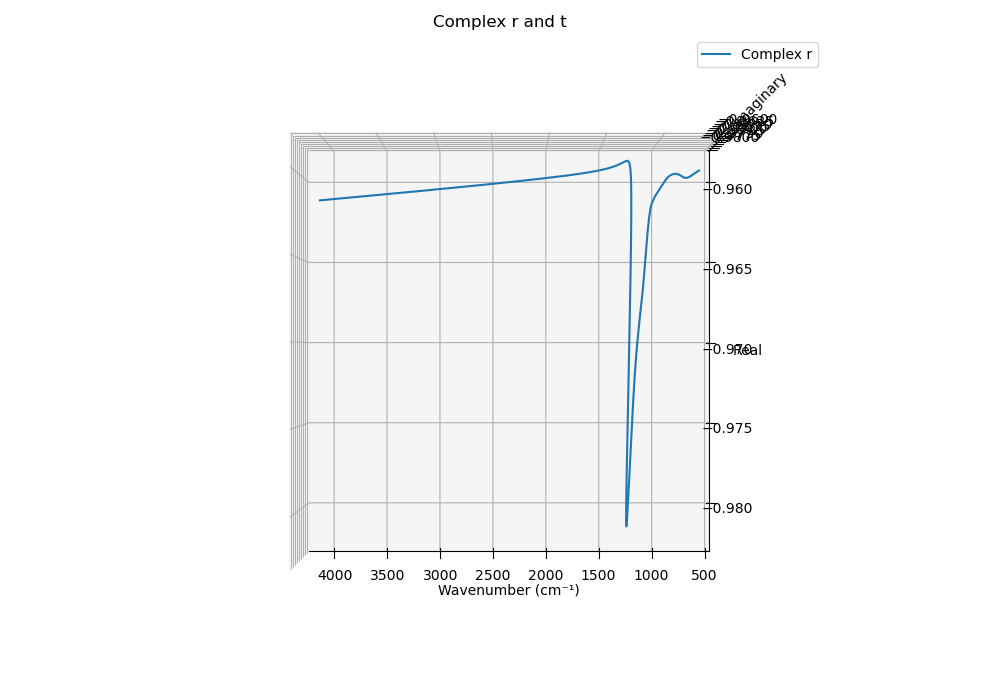

In [82]:
%matplotlib widget 

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd     

df = pd.read_excel("/Users/josephschellenberg/Downloads/Fresnell/Fresnell.xlsx")  # Or .csv with pd.read_csv

# Extract columns into arrays
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values
n2_array = df["n2"].values
k2_array = df["k2"].values 


def plot_vs_wavenumber(wave_numbers, n0_array, n1_array, n2_array, 
                       k0_array, k1_array, k2_array, d, th0, mode="Reflectance and Transmittence"):
    R_p, R_s, T_p, T_s = [], [], [], []

    for i in range(len(wave_numbers)):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        Wavelength = 10000 / wave_numbers[i]  # Convert from cm⁻¹ to nm or μm
        cos_th0 = cos(th0)
        th1 = snells(n0, n1, k0, k1, th0)
        cos_th1 = cos(th1) 
        th2 = snells(n1, n2, k1, k2, th1)
        cos_th2= cos(th2)
        r_p = r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        r_s = r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        t_p = t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        t_s = t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)

        if mode == "Reflectance and Transmittence":
            R_p.append(np.abs(r_p)**2)
            R_s.append(np.abs(r_s)**2)
            T_p.append((n2+k2)*cos_th2*(np.abs(t_p)**2)/(n0+k0)/cos_th0)
            T_s.append((n2+k2)*cos_th2*(np.abs(t_s)**2)/(n0+k0)/cos_th0)
        else:
            R_p.append(r_p)
            R_s.append(r_s)
            T_p.append(t_p)
            T_s.append(t_s)

    plt.figure(figsize=(10, 6))
    plt.plot(wave_numbers, R_s, 'r--', label='R_s')
    plt.plot(wave_numbers, T_s, 'b--', label='T_s')
    plt.plot(wave_numbers, R_p, 'r-', label='R_p')
    plt.plot(wave_numbers, T_p, 'b-', label='T_p')
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Reflectance and Transmittence" if mode == "abs" else "Spectra")
    plt.title(f"Fresnel Coefficients at θ = {th0}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.gca().invert_xaxis()
    plt.show()


def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))



# 4 General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 

def t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

# 5 General form of fresnel coefficients for p polarized light (parrallel electric field)  

def r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#transmission matrix 

def D_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  

def D_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  


# propagation matrix wich is independant of polarazation

def P(ni, nt, ki, kt, thi, d, Wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength),0],[0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength)]]))


def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11) 


def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1) 
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   

def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 

def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)  







#plot_vs_wavenumber(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=.001, th0=80)  #d needs to be in micro meters.  


from mpl_toolkits.mplot3d import Axes3D

def plot_3D(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d, th0, mode='0', polarization='p', view = 'xy'):
    
    def Fresnell_rtot_ttot(polarization, i):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        wavelength = 10000 / wave_numbers[i]
        if polarization == 'p':
            return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
        else:
            return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  
   
    
    fig = plt.figure(figsize=(10, 7))              #Creating my graphing figure
    ax = fig.add_subplot(111, projection='3d')

    
    if mode == '0':
        ax.set_ylabel('n1')
        ax.set_zlabel('k1')
        ax.set_title(f'Complex index')
        ax.plot(wave_numbers, n1_array, k1_array, label=f'Complex refractive index')

    if mode == '1':
        r_Re_list, r_Im_list, t_Re_list, t_Im_list  = [], [], [], []
        for i in range(len(wave_numbers)):
            r, t = Fresnell_rtot_ttot(polarization, i)   
            r_Re_list.append(np.real(r))
            r_Im_list.append(np.imag(r))        
            #t_Re_list.append(np.real(t))
            #t_Im_list.append(np.imag(t))              
        
        ax.set_ylabel('Real')
        ax.set_zlabel('Imaginary')
        ax.set_title(f'Complex r and t')
        #ax.plot(wave_numbers, t_Re_list, t_Im_list, label=f'Complex t')
        ax.plot(wave_numbers, r_Re_list, r_Re_list, label=f'Complex r')  

    #ax.set_title(f'Complex {polarization}-polarized reflection coefficient vs. wavenumber') {} lets the name change based on mode
          

    else:
        plt.text(0.5, 0.5, f"Unsupported mode: {mode}", ha='center')
  
    
    #this allows us to choose a viewing axis    
    if view == 'xy':
        ax.view_init(elev=90, azim=-90)  
    elif view == 'xz':
        ax.view_init(elev=0, azim=0)    
    elif view == 'yz':
        ax.view_init(elev=0, azim=90)    
    elif view == 'isometric':
        ax.view_init(elev=30, azim=45)   
  
   

    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.invert_xaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()   

plot_3D(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=0.001, th0=80, mode='1', polarization='p', view='xy')






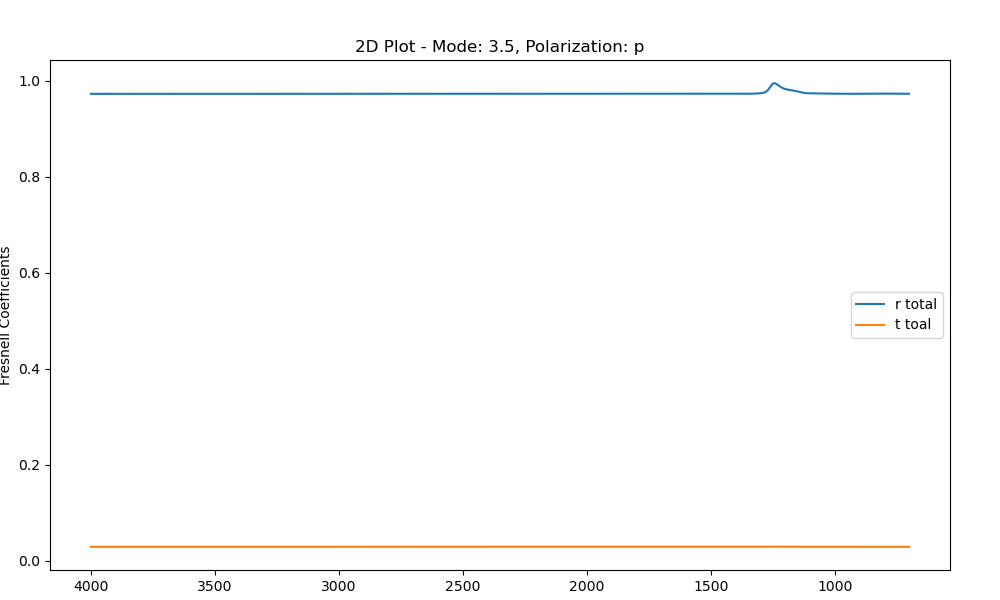

In [88]:
# Mode 0 graphs n and k values for the n0 medium

# Mode 1 graphs n and k values for the n1 medium

# Mode 2 graphs n and k values for the n2 medium

# Mode 3 plots the fresnell coeeficints over wavelenght 

# mode 4 plots Reflectance. more specifically the (magnitude of r)^2 aka r*rconjugate  

# mode 5 plots Reflectance. more specifically the real part and the imaginary part. Re(r^2)  Im(r^2)

# mode 6 plots the absorbtance of the materiarial when the system has no net transmission. Im denoting it 'a'. From kirkoffs law a+T+R=1. 
# For example when a film is on metal t=0 so a+T+R=1=a+R. So we find a to be 1-R. 

# mode 7 plots the absorbance from the absorbtance of mode 6. I denoted it A it is just the log 1/a in this situation. The naming of these is confusing i did not choose them. 

# Mode 8 plots Trasmittence. Check your n and k values for the exell file to make sure your 3rd medium is capable of transmitting.
# mode 9 plots the Absorbance 'A' when there is transmission and reflection.   
#mode 10 shows the phase shift
# thats all the modes for now. There are tons of combination graphs Might make in the futre like plotting n, k, and absoption all on the same graph. 

def Fresnellbkg(polarization, i):          #creates backround for our spectra calculation we arent using this now but may be useful later to ratio our spectra
    n0, n2 = n0_array[i], n2_array[i]
    k0, k2 = k0_array[i], k2_array[i]
    wavelength = 10000 / wave_numbers[i]
    if polarization == 'p':
        return r_p(n0, n2, k0, k2, 80, mui=8.85*10**-12, mut=8.85*10**-12), t_p(n0, n2, k0, k2, 80, mui=8.85*10**-12, mut=8.85*10**-12)
    else:
        return r_s(n0, n2, k0, k2, 80, mui=8.85*10**-12, mut=8.85*10**-12), t_s(n0, n2, k0, k2, 80, mui=8.85*10**-12, mut=8.85*10**-12)



def Spectraplot(wave_numbers, n0_array, n1_array, n2_array,k0_array, k1_array, k2_array, d, th0, mode='0', polarization='p'):
    plt.figure(figsize=(10, 6))
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.gca().invert_xaxis()

    def Fresnell_rtot_ttot(polarization, i):
        n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]
        k0, k1, k2 = k0_array[i], k1_array[i], k2_array[i]
        wavelength = 10000 / wave_numbers[i]
        if polarization == 'p':
            return r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)
        else:
            return r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength), t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, wavelength)  


    if mode == '0':
        plt.plot(wave_numbers, n0_array, label='n0')
        plt.plot(wave_numbers, k0_array, label='k0')
        plt.ylabel('Optical constants')
    
    
    elif mode == '1':
        plt.plot(wave_numbers, n1_array, label='n1')
        plt.plot(wave_numbers, k1_array, label='k1')
        plt.ylabel('Optical constants')
    
    
    elif mode == '2':
        plt.plot(wave_numbers, n2_array, label='n2')
        plt.plot(wave_numbers, k2_array, label='k2')
        plt.ylabel('Optical constants')
    
    elif mode == '3':
        r_list, t_list = [], []
        for i in range(len(wave_numbers)):
            r, t = Fresnell_rtot_ttot(polarization, i)   
            r_list.append(np.real(r))
            t_list.append(np.real(t))
        plt.plot(wave_numbers, r_list, label='r total')
        plt.plot(wave_numbers, t_list, label='t toal')
        plt.ylabel('Fresnell Coefficients') 
  
    elif mode == '3.5':
        r_list, t_list = [], []
        for i in range(len(wave_numbers)):
            r, t = Fresnell_rtot_ttot(polarization, i)   
            r_list.append(np.abs(r))
            t_list.append(np.abs(t))
        plt.plot(wave_numbers, r_list, label='r total')
        plt.plot(wave_numbers, t_list, label='t toal')
        plt.ylabel('Fresnell Coefficients')
     
    
    elif mode == '4':
        R = []
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value. 
            R.append(np.abs(r)**2)
        plt.plot(wave_numbers, R, label='R')
        plt.ylabel('Reflectance---|r|^2')   
    
    elif mode == '5':
        RealR,  ImR = [], []
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value. 
            RealR.append(np.real(r**2))
            ImR.append(np.imag(r**2))
        plt.plot(wave_numbers, RealR, label='Real') 
        plt.plot(wave_numbers, ImR, label='Imagenary')
        plt.ylabel('Reflectance---real vs imaginary')     

    elif mode == '6':
        Absorbtance = [] #creates empty list to store entries
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value.  
            R = np.abs(r)**2
            a = 1 - R 
            Absorbtance.append(a)    #adds an entry to the list 
        plt.plot(wave_numbers, Absorbtance, label='Absorbtance') 
        plt.ylabel('Absorbtance')    
   
    elif mode == '7':
        Absorbance = [] #creates empty list to store entries
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the t value.  
            R = np.abs(r)**2
            a = 1 - R 
            A = np.log10(1/a)
            Absorbance.append(A)    #adds an entry to the list 
        plt.plot(wave_numbers, Absorbance, label='Absorbance') 
        plt.ylabel('Absorbance')    
    
    elif mode == '8':
        Transmittence = [] #creates empty list to store entries
        for i in range(len(wave_numbers)):
            n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]     # need to redefine variables inside of loop
            k0, k1, k2 = k0_array[i], k0_array[i], k2_array[i]
            cos_th0 = cos(th0)
            th1 = snells(n0, n1, k0, k1, th0)  #Im recaulculating theta 1 and 2 in the loop because they depend on n and k wich vary per wavelength.
            cos_th1 = cos(th1) 
            th2 = snells(n1, n2, k1, k2, th1)
            cos_th2= cos(th2) 
            
            _, t = Fresnell_rtot_ttot(polarization, i)   #_ underscore throws away the r value.  
            T = np.real((n2 * cos_th2) / (n0 * cos_th0)) * np.abs(t)**2
            Transmittence.append(T)    #adds an entry to the list 
        plt.plot(wave_numbers, Transmittence, label='Transmittence') 
        plt.ylabel('Transmittence')     

    elif mode == '9':
        Absorbance = [] #creates empty list to store entries
        for i in range(len(wave_numbers)):
            n0, n1, n2 = n0_array[i], n1_array[i], n2_array[i]     # need to redefine variables inside of loop
            k0, k1, k2 = k0_array[i], k0_array[i], k2_array[i]
            cos_th0 = cos(th0)
            th1 = snells(n0, n1, k0, k1, th0)  #Im recaulculating theta 1 and 2 in the loop because they depend on n and k wich vary per wavelength.
            cos_th1 = cos(th1) 
            th2 = snells(n1, n2, k1, k2, th1)
            cos_th2= cos(th2) 
            r, t = Fresnell_rtot_ttot(polarization, i)     
            T = np.real((n2 * cos_th2) / (n0 * cos_th0)) * np.abs(t)**2 
            R = np.abs(r)**2 
            a = 1 - R -T 
            A = np.log10(1/a)
            Absorbance.append(A)    #adds an entry to the list 
        plt.plot(wave_numbers, Absorbance, label='Absorbance') 
        plt.ylabel('Absorbance')    
    
    elif mode == '10':
        phase = []
        for i in range(len(wave_numbers)):
            r, _ = Fresnell_rtot_ttot(polarization, i)
            phase.append(np.angle(r))
        plt.plot(wave_numbers, phase, label='arg(r)')
        plt.ylabel('Phase of r')

    else:
        plt.text(0.5, 0.5, f"Unsupported mode: {mode}", ha='center')

    plt.title(f"2D Plot - Mode: {mode}, Polarization: {polarization}")
    plt.legend()
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.90)
    plt.show()





Spectraplot(wave_numbers, n0_array, n1_array, n2_array, k0_array, k1_array, k2_array, d=.0010, th0=80, mode='3.5', polarization='p')